In [1]:
import funcs
import time
import importlib

In [2]:
importlib.reload(funcs)

<module 'funcs' from '/home/thomas/Documents/Formations/OpenClassRooms/OC-formation-Ingenieur-Machine-Learning/Projetcs/06_Classer_images_DL/funcs.py'>

In [3]:
path_data = 'data/source/images/'
path_data_save = 'data/cleaned/images/'
target_shape = 224, 224
n_kept_classes = 10


In [4]:
part_to_run = [
    # 'init dataset',
    # 'modelisation initiale',
    'modelisation optimizer',
    'modelisation AE'
]

# Prépartion du dataset

In [5]:
part = 'init dataset'
if part in part_to_run:
    infos = funcs.get_filenames_labels_and_count(path_data)
    funcs.display_n_images_per_class(infos)

In [6]:
if part in part_to_run:
    funcs.plot_classes(infos, n_kept_classes)

In [7]:
if part in part_to_run:
    funcs.get_kept_classes_and_folders(infos, path_data, n_kept_classes)
    display(infos['df kept classes'])

In [8]:
if part in part_to_run:
    funcs.read_image_shapes(path_data, infos)

In [9]:
if part in part_to_run:
    funcs.plot_image_shapes(infos)

In [10]:
if part in part_to_run:
    funcs.load_resize_save_images(infos, path_data, path_data_save, target_shape)

In [11]:
if part in part_to_run:
    funcs.create_annotations_files(infos, path_data_save)

---

Nombre de classes dans le dataset: 10
Nombre de classes dans le dataset: 10


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


image type: <class 'torch.Tensor'> tensor(1., device='cuda:0')
label: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0') argmax: 0


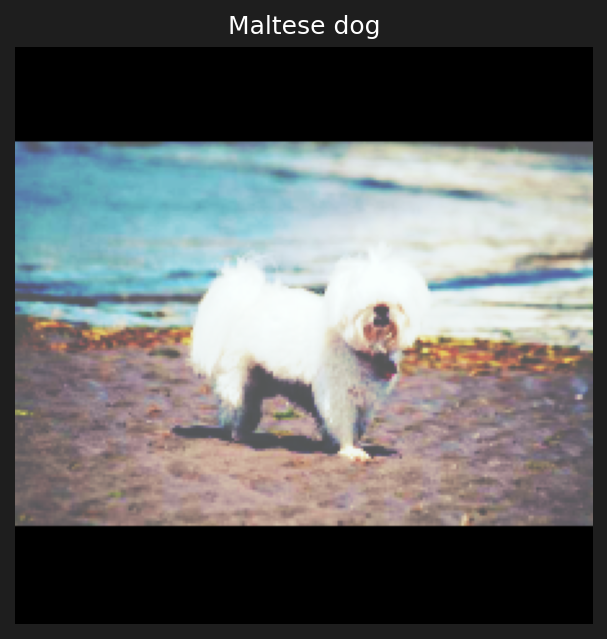

In [12]:
# pas de test car requis
train_data = funcs.CustomImageDataset('train', path_data_save)
test_data = funcs.CustomImageDataset('test', path_data_save)

funcs.test_class_dataset(train_data)

dataloaders = funcs.define_data_loaders(train_data, test_data)

# Modélisation

In [13]:
part = 'modelisation initiale'
epochs = 30
optimizer_info = {'name': 'SGD', 'params':{'lr': 1e-1}}
names = []

In [14]:
model = funcs.NeuralNetwork(n_kept_classes)
model.set_breakpoint()
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv_stack): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding

In [15]:
name = 'initial raw images'
names.append(name)
if part in part_to_run:
    importlib.reload(funcs)

    accuracies, losses = funcs.train_network(model, epochs, dataloaders, optimizer_info)

    # model.save_to_file(name)
    funcs.to_pickle(f'results/{name}', {'accuracy': accuracies,
                                        'loss': losses})

In [16]:
if part in part_to_run:
    train_data.normalize_images()
    test_data.normalize_images()

In [17]:
name = 'initial normalized images'
names.append(name)
if part in part_to_run:

    model.reload_breakpoint()
    accuracies, losses = funcs.train_network(model, epochs, dataloaders, optimizer_info)

    # model.save_to_file(name)
    funcs.to_pickle(f'results/{name}', {'accuracy': accuracies,
                                        'loss': losses})

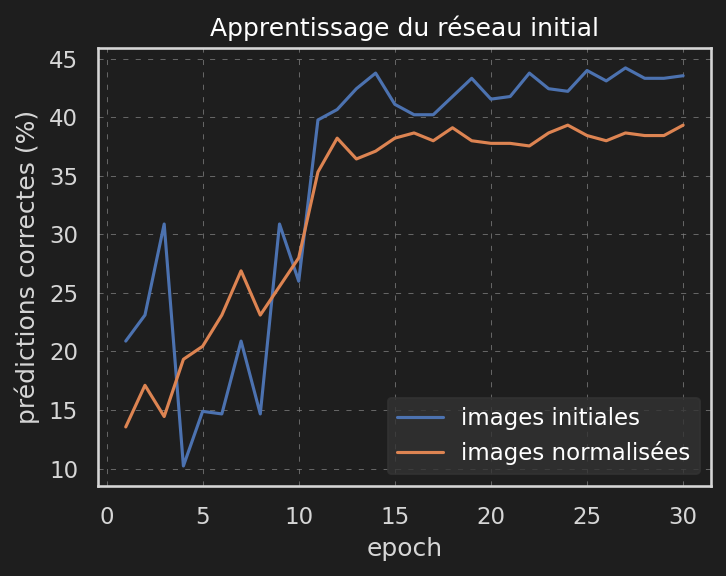

In [18]:
importlib.reload(funcs)
results = {}
for name, label in zip(names, ['images initiales', 'images normalisées']):
    results[name] = funcs.load_pickle(f'results/{name}')
    results[name]['label'] = label
funcs.plot_accuracies_vs_epochs("Apprentissage du réseau initial",
                                'initial_learn',
                                results)

## Data augmentation

In [19]:
train_data.transform = funcs.data_augmentation_transform()
test_data.transform = funcs.data_augmentation_transform()

In [20]:
name = 'initial data augmentation'
names.append(name)
if part in part_to_run:

    model.reload_breakpoint()
    accuracies, losses = funcs.train_network(model, epochs, dataloaders, optimizer_info)

    # model.save_to_file(name)
    funcs.to_pickle(f'results/{name}', {'accuracy': accuracies,
                                        'loss': losses})

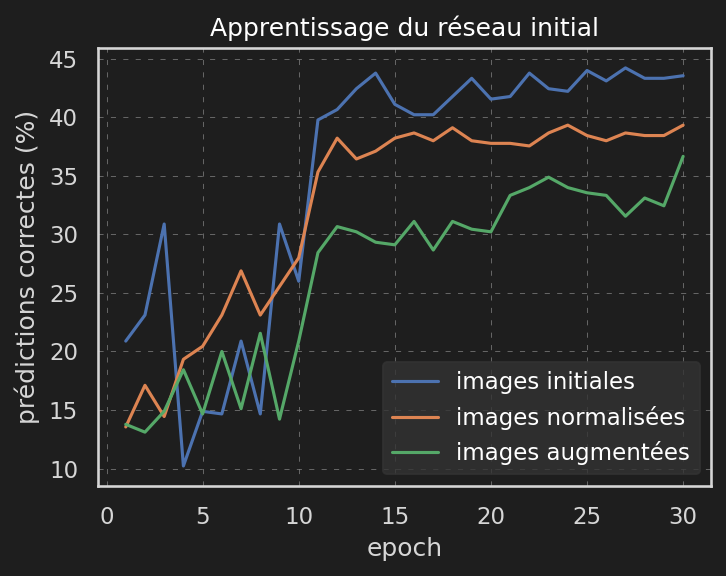

In [21]:
results = {}
for name, label in zip(names, ['images initiales',
                               'images normalisées',
                               'images augmentées']):
    results[name] = funcs.load_pickle(f'results/{name}')
    results[name]['label'] = label
funcs.plot_accuracies_vs_epochs("Apprentissage du réseau initial",
                                'initial_learn',
                                results)

## Optimizer

* ADADELTA


In [22]:
part = 'modelisation optimizer'
if part in part_to_run:
    importlib.reload(funcs)

    optimizers_infos = [
        ('Adadelta', {'lr': 1., 'rho': 0.}),
        ('ASGD', {'lr': 0.01, 't0': 10}),
        ('Adagrad', {'lr': 0.01}),
        ('Adam', {'lr': 0.001}),
        # ('LBFGS', {'lr': 1.}),  # trop de mémoire requise en gpu
        ('RMSprop', {}),
        ('Rprop', {})
    ]
    
    compute_time = {}
    for (name, params) in optimizers_infos:
        model.reload_breakpoint()
        t0 = time.time()
        accuracies, losses = funcs.train_network(model, epochs, dataloaders,
                                        {'name': name, 'params': params})
        compute_time[name] = time.time()-t0
        # model.save_to_file(name)
        funcs.to_pickle(f'results/optimizers/{name}', {'accuracy': accuracies,
                                                       'loss': losses})
    funcs.to_pickle('results/compute_time', compute_time)

Epoch 1
-------------------------------
loss: 2.583816  [   32/ 1783]
loss: 2.585863  [  352/ 1783]
loss: 3.178702  [  672/ 1783]
loss: 2.846115  [  992/ 1783]
loss: 2.086606  [ 1312/ 1783]
loss: 2.838221  [ 1632/ 1783]
Test Error: 
 Accuracy: 12.9%, Avg loss: 3.680285 

Epoch 2
-------------------------------
loss: 2.598156  [   32/ 1783]
loss: 2.736131  [  352/ 1783]
loss: 3.287745  [  672/ 1783]
loss: 2.978506  [  992/ 1783]
loss: 3.461424  [ 1312/ 1783]
loss: 2.662121  [ 1632/ 1783]
Test Error: 
 Accuracy: 15.1%, Avg loss: 3.633536 

Epoch 3
-------------------------------
loss: 2.570025  [   32/ 1783]
loss: 3.411682  [  352/ 1783]
loss: 2.937815  [  672/ 1783]
loss: 2.972602  [  992/ 1783]
loss: 2.944993  [ 1312/ 1783]
loss: 3.550794  [ 1632/ 1783]
Test Error: 
 Accuracy: 15.8%, Avg loss: 3.220447 

Epoch 4
-------------------------------
loss: 3.096884  [   32/ 1783]
loss: 2.814237  [  352/ 1783]
loss: 3.581587  [  672/ 1783]
loss: 3.297999  [  992/ 1783]
loss: 3.272069  [ 1312/ 

<span style="color:red"> AJOUT GRAPH COMPUTE TIME + SGD </span>

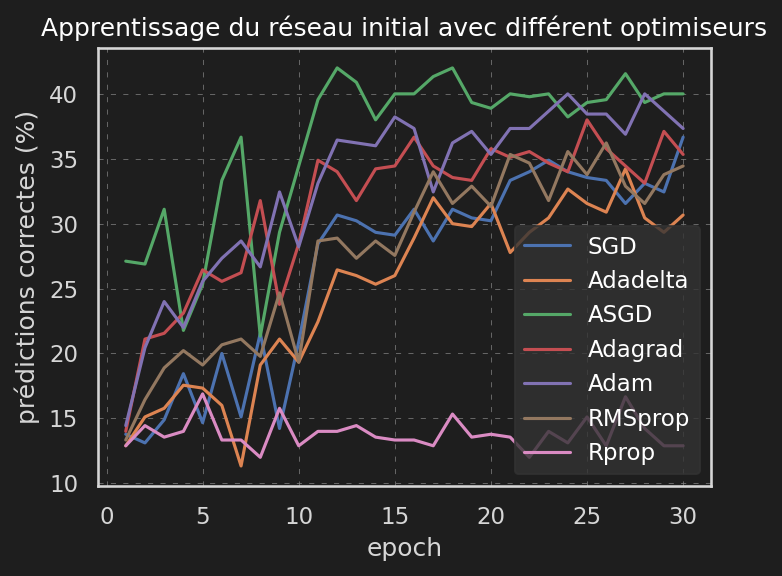

In [23]:
results = {}
name = 'initial data augmentation'
results[name] = funcs.load_pickle(f'results/{name}')
results[name]['label'] = 'SGD'
for name, _ in optimizers_infos:
    results[name] = funcs.load_pickle(f'results/optimizers/{name}')
    results[name]['label'] = name

funcs.plot_accuracies_vs_epochs(
        "Apprentissage du réseau initial avec différent optimiseurs",
        'initial_learn_optimizers',
        results)

## Essai avec un auto-encodeur

In [24]:
part = 'modelisation AE'
epochs = 50
optimizer_info = {'name': 'SGD', 'params':{'lr': 1e-1}}

In [25]:
importlib.reload(funcs)

name = 'autoencoder 0'
model_ae = funcs.NeuralNetwork_AE_based()
model_ae.set_breakpoint()
print(model_ae)

NeuralNetwork_AE_based(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (conv_stack): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2

In [26]:
if part in part_to_run:
    importlib.reload(funcs)
    mse, loss = funcs.train_network_ae(model_ae, epochs, dataloaders,
                                  optimizer_info)

Epoch 1
-------------------------------
loss: 2.380525  [   32/ 1783]
loss: 1.410899  [  352/ 1783]
loss: 1.368501  [  672/ 1783]
loss: 1.366757  [  992/ 1783]
loss: 1.279185  [ 1312/ 1783]
loss: 1.434210  [ 1632/ 1783]
Test Error: 
MSE: 205721.93750, Avg loss: 1.356634 

Epoch 2
-------------------------------
loss: 1.348969  [   32/ 1783]
loss: 1.334844  [  352/ 1783]
loss: 1.289930  [  672/ 1783]
loss: 1.335450  [  992/ 1783]
loss: 1.193632  [ 1312/ 1783]
loss: 1.238351  [ 1632/ 1783]
Test Error: 
MSE: 197320.31250, Avg loss: 1.315210 

Epoch 3
-------------------------------
loss: 1.350574  [   32/ 1783]
loss: 1.311627  [  352/ 1783]
loss: 1.321308  [  672/ 1783]
loss: 1.275345  [  992/ 1783]
loss: 1.262616  [ 1312/ 1783]
loss: 1.204561  [ 1632/ 1783]
Test Error: 
MSE: 196895.84375, Avg loss: 1.305646 

Epoch 4
-------------------------------
loss: 1.283692  [   32/ 1783]
loss: 1.280207  [  352/ 1783]
loss: 1.226997  [  672/ 1783]
loss: 1.245667  [  992/ 1783]
loss: 1.371527  [ 131

In [27]:
# import matplotlib.pylab as plt
# import pandas as pd
# import numpy as np
# import time
# from IPython import display
# %matplotlib inline

# i = pd.date_range('2013-1-1',periods=100,freq='s')

# while True:
#     try:
#         plt.plot(pd.Series(data=np.random.randn(100), index=i))
#         display.display(plt.gcf())
#         display.clear_output(wait=True)
#         time.sleep(1)
#     except KeyboardInterrupt:
#         break

test: tensor(0., device='cuda:0') tensor(0.9049, device='cuda:0')
reconstructed: tensor(0., device='cuda:0') tensor(0.8673, device='cuda:0')


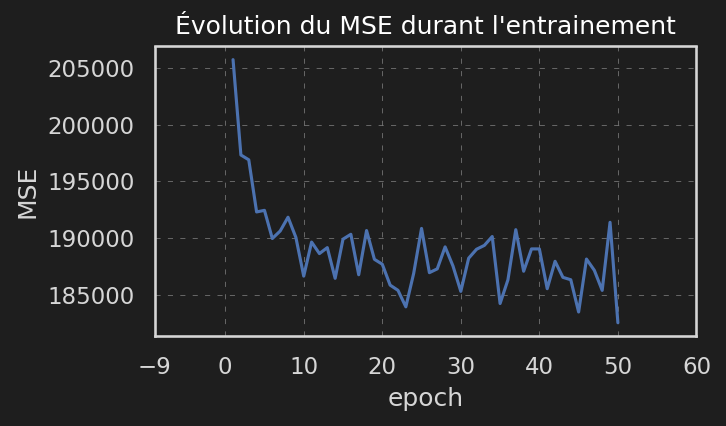

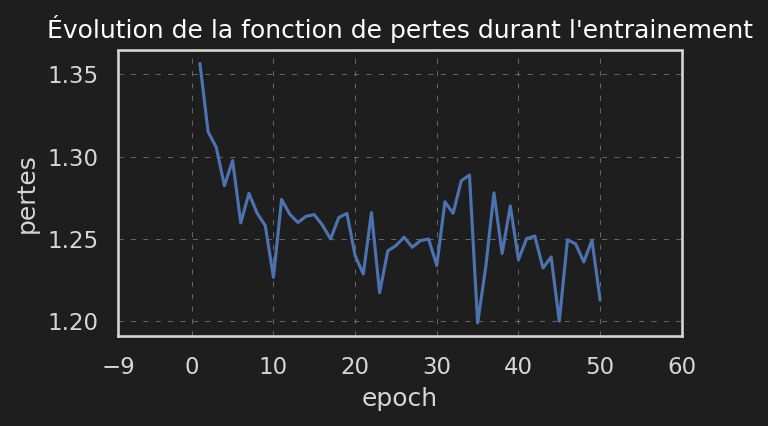

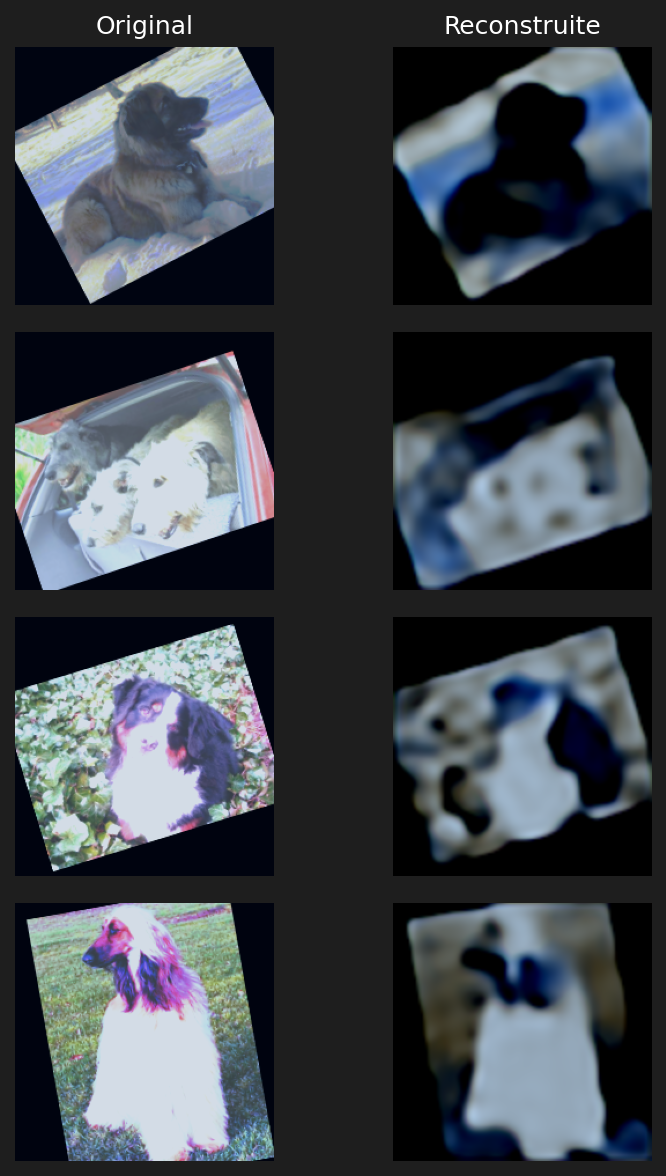

In [28]:
importlib.reload(funcs)
funcs.plot_ae_results(model_ae, dataloaders['train'], mse, loss)

In [29]:
model_ae.set_breakpoint()

In [30]:
model_ae.drop_decoder()
model_ae.lock_encoder()
model_ae.to_classifier(n_kept_classes)

In [31]:
accuracies, losses = funcs.train_network(model_ae, epochs, dataloaders, optimizer_info)
funcs.to_pickle(f'results/{name}', {'accuracy': accuracies,
                                    'loss': losses})

Epoch 1
-------------------------------
loss: 2.456497  [   32/ 1783]
loss: 3.067852  [  352/ 1783]
loss: 2.638900  [  672/ 1783]
loss: 3.662300  [  992/ 1783]
loss: 2.899060  [ 1312/ 1783]
loss: 3.282171  [ 1632/ 1783]
Test Error: 
 Accuracy: 13.6%, Avg loss: 3.434236 

Epoch 2
-------------------------------
loss: 3.229972  [   32/ 1783]
loss: 3.354930  [  352/ 1783]
loss: 3.212989  [  672/ 1783]
loss: 2.958152  [  992/ 1783]
loss: 3.951162  [ 1312/ 1783]
loss: 3.140643  [ 1632/ 1783]
Test Error: 
 Accuracy: 18.9%, Avg loss: 2.922625 

Epoch 3
-------------------------------
loss: 2.691937  [   32/ 1783]
loss: 2.967069  [  352/ 1783]
loss: 2.546468  [  672/ 1783]
loss: 2.471459  [  992/ 1783]
loss: 4.110402  [ 1312/ 1783]
loss: 3.051917  [ 1632/ 1783]
Test Error: 
 Accuracy: 16.2%, Avg loss: 3.401995 

Epoch 4
-------------------------------
loss: 3.958730  [   32/ 1783]
loss: 3.516233  [  352/ 1783]
loss: 3.100478  [  672/ 1783]
loss: 3.993046  [  992/ 1783]
loss: 3.194026  [ 1312/ 

<span style="color:red"> FAIRE DES ESSAIS POUR DIFFERENTS EPOCHS </span>

In [32]:
name2 = name + '_finetuned'
optimizer_info = {'name': 'SGD', 'params':{'lr': 1e-3}}

model_ae.unlock_encoder()
accuracies, losses = funcs.train_network(model_ae, epochs, dataloaders, optimizer_info)
funcs.to_pickle(f'results/{name2}', {'accuracy': accuracies,
                                                       'loss': losses})

Epoch 1
-------------------------------
loss: 2.222260  [   32/ 1783]
loss: 2.309459  [  352/ 1783]
loss: 2.211956  [  672/ 1783]
loss: 2.040026  [  992/ 1783]
loss: 2.373734  [ 1312/ 1783]
loss: 2.192456  [ 1632/ 1783]
Test Error: 
 Accuracy: 30.0%, Avg loss: 1.871483 

Epoch 2
-------------------------------
loss: 1.890315  [   32/ 1783]
loss: 2.005939  [  352/ 1783]
loss: 2.144697  [  672/ 1783]
loss: 2.426207  [  992/ 1783]
loss: 2.000131  [ 1312/ 1783]
loss: 2.023273  [ 1632/ 1783]
Test Error: 
 Accuracy: 33.1%, Avg loss: 1.848655 

Epoch 3
-------------------------------
loss: 1.562269  [   32/ 1783]
loss: 1.888695  [  352/ 1783]
loss: 1.756377  [  672/ 1783]
loss: 2.167176  [  992/ 1783]
loss: 2.277277  [ 1312/ 1783]
loss: 1.923257  [ 1632/ 1783]
Test Error: 
 Accuracy: 33.1%, Avg loss: 1.841124 

Epoch 4
-------------------------------
loss: 1.839331  [   32/ 1783]
loss: 2.222114  [  352/ 1783]
loss: 2.042318  [  672/ 1783]
loss: 1.998461  [  992/ 1783]
loss: 2.149438  [ 1312/ 

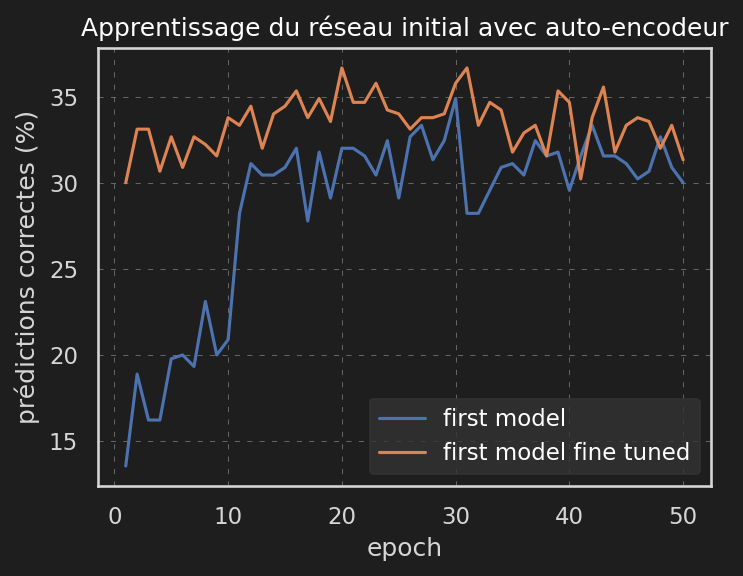

In [33]:
results = {}

results[name] = funcs.load_pickle(f'results/{name}')
results[name]['label'] = 'first model'

results[name2] = funcs.load_pickle(f'results/{name2}')
results[name2]['label'] = 'first model fine tuned'


funcs.plot_accuracies_vs_epochs(
        "Apprentissage du réseau initial avec auto-encodeur",
        'initial_learn_AE',
        results)

---

<span style="color:orange"> UTILISER PARAMETRE OPTIMISATION PAR PARTIE </span>

In [ ]:
optim.SGD([
                {'params': model.base.parameters()},
                {'params': model.classifier.parameters(), 'lr': 1e-3}
            ], lr=1e-2, momentum=0.9)

---

In [ ]:
vgg16 = funcs.load_vgg16()

Model "VGG16" structure: VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride

<span style="color:red"> todo: ajout construction avec paramètres: </span>
> * nombre de super couches de convolution
> * nombre de couches par super couche

# AH

---

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")
if device == 'cuda':
    print(torch.cuda.get_device_name(torch.cuda.current_device()))

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

In [ ]:
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")

In [ ]:
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")